# Customer Segmentation using Machine Learning

## Objective

The objective of this notebook is to identify meaningful customer segments using unsupervised machine learning.

Unlike traditional demographic segmentation, this analysis groups customers according to their purchasing behavior.

The resulting customer personas can be used for:

- Personalized marketing
- Customer retention
- Loyalty programs
- Product recommendations
- Customer Lifetime Value prediction

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
project_root = Path.cwd().parent.parent
data_dir = project_root / "datasets" / "Olist"


In [3]:
orders = pd.read_csv(data_dir/"olist_orders_dataset.csv",
                     parse_dates=["order_purchase_timestamp"])
payments = pd.read_csv(data_dir/"olist_order_payments_dataset.csv")

customers = pd.read_csv(data_dir/"olist_customers_dataset.csv")

In [4]:
# building customer table 
customer_df=(
    customers
    .merge(orders,
           on="customer_id")
    .merge(
        payments,
        on="order_id"
    )
)
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,credit_card,8,252.25


In [5]:
snapshot = (
    customer_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
)

In [6]:
# creating ML features 
features = (
    customer_df
    .groupby("customer_unique_id")
    .agg(
        Recency = (
            "order_purchase_timestamp",
            lambda x: (snapshot-x.max()).days
        ),
        Frequency=(
            "order_id",
            "nunique"
        ),
        Monetary=(
            "payment_value",
            "sum"
        ),
        AvgOrderValue=(
            "payment_value",
            "mean"
        )
    )
)
features.head()

,Recency,Frequency,Monetary,AvgOrderValue
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89


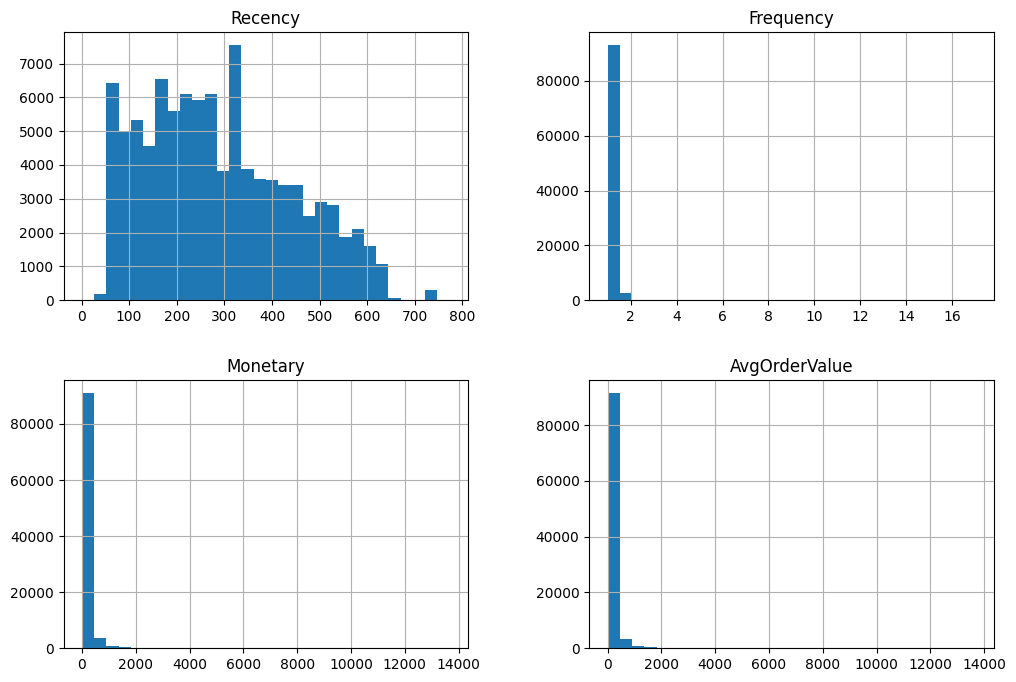

In [7]:
features.hist(
    figsize=(12,8),
    bins=30
)
plt.show()

In [8]:
features["Monetary"] = np.log1p(
    features["Monetary"]
)
features["Frequency"] = np.log1p(
    features["Frequency"]
)

features["AvgOrderValue"] = np.log1p(
    features["AvgOrderValue"]
)

In [9]:
# scaling 
scaler = StandardScaler()
x= scaler.fit_transform(features)

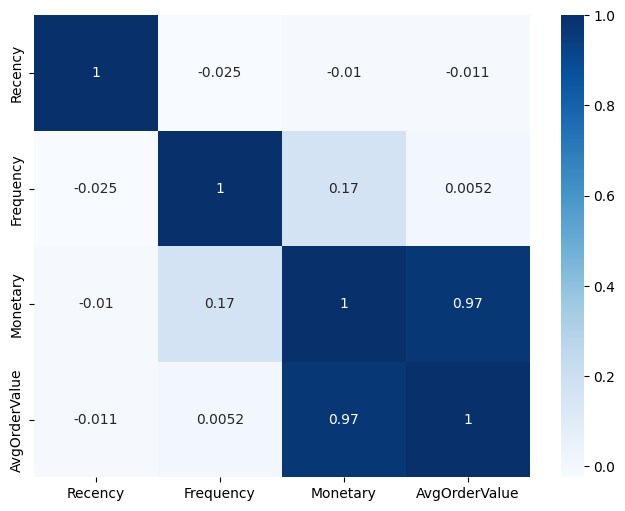

In [10]:
# correlation 
plt.figure(figsize=(8,6))
sns.heatmap(
    features.corr(),
    annot=True,
    cmap="Blues"
)
plt.show()

In [12]:
from sklearn.cluster import KMeans

# Elbow Method
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(x)
    inertia.append(model.inertia_)

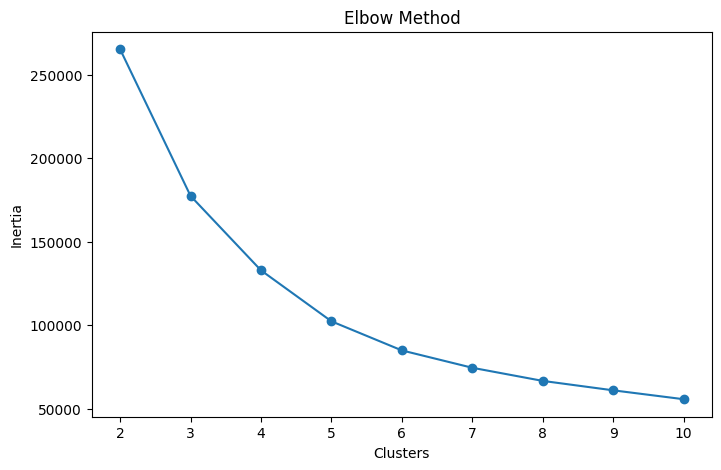

In [13]:
plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    inertia,
    marker="o"
)
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [14]:
# silhoutte score: Used to calculate how well a point is within a cluster. Ranges between -1 to 1
scores =[]
for k in range(2,11):
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels= model.fit_predict(x)
    scores.append(
        silhouette_score(x,labels)
    )


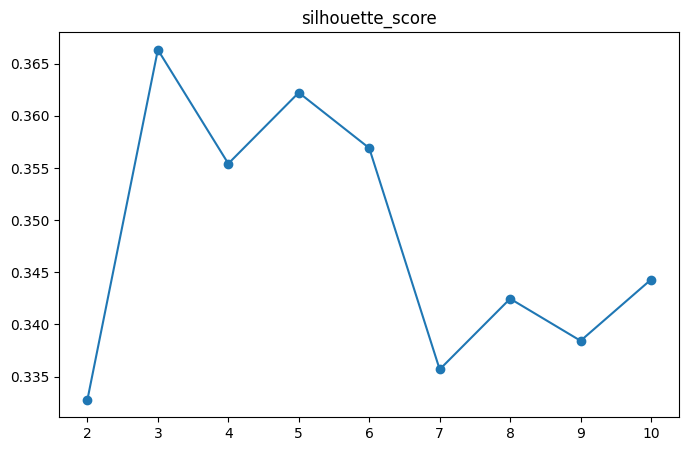

In [15]:
plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    scores,
    marker='o'
)
plt.title("silhouette_score")
plt.show()

In [16]:
# so k=3 is the best number 
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)
features["Cluster"] = kmeans.fit_predict(x)

In [17]:
pca=PCA(n_components=2)
components = pca.fit_transform(x)
plot_df = pd.DataFrame({
    "PC1":components[:,0],
    "PC2":components[:,1],
    "Cluster":features["Cluster"]
})

In [18]:
# visulization 
fig = px.scatter(
    plot_df,

    x="PC1",
    y="PC2",
    color = "Cluster",
    title="Customer Segments",
    template="plotly_white"
)
fig.show()

In [19]:
# cluster profiling
cluster_profile=(
    features
    .groupby("Cluster")
    .mean()
    .round(2)
)
cluster_profile

,Recency,Frequency,Monetary,AvgOrderValue
Cluster,,,,
0,470.40,0.69,4.44,4.41
1,254.38,0.69,5.55,5.54
2,269.21,1.13,5.47,4.71
3,194.37,0.69,4.16,4.13


In [20]:
cluster_sizes=(
    features["Cluster"]
    .value_counts()
    .reset_index()
)
cluster_sizes.columns=[
    "Cluster",
    "Customer"
]


In [21]:
fig = px.pie(
    cluster_sizes,
    names="Cluster",
    values="Customer",
    title="Customer Distribution Across Clusters"
)
fig.show()

In [22]:
cluster_profile = (
    features
    .groupby("Cluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean",
        "AvgOrderValue": "mean"
    })
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary,AvgOrderValue
Cluster,,,,
0,470.40,0.69,4.44,4.41
1,254.38,0.69,5.55,5.54
2,269.21,1.13,5.47,4.71
3,194.37,0.69,4.16,4.13
